# Kenbec Field-Data Inversion

Inverts the stacked TEMImage-Beta station data using pyTEM.

1. Read the file and inspect waveforms / gate times.
2. Plot raw soundings and per-gate SNR.
3. Prepare inversion inputs for **both moments** (LM + HM) with `to_pytem`.
4. Define a smooth multi-layer starting model.
5. Run a **joint** regularised Gauss-Newton inversion of LM + HM (per-moment
   waveform convolution, offset circular loop) for a single resistivity model.
6. Inspect data fit, convergence, and recovered resistivity profile.


In [ ]:
import sys, importlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Locate the pyTEM repo root (the folder containing the `pytem` package and
# read_kenbec_xyz.py) by searching upward from the working directory, so no
# absolute path is needed.
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Force reload so changes to read_kenbec_xyz.py are always picked up
import read_kenbec_xyz as _rkxyz
importlib.reload(_rkxyz)
from read_kenbec_xyz import read_kenbec_xyz

from pytem import invert, fwd_circle_offset, convolve_waveform
from pytem.plotter import plot_inversion

## 1. Read the file

In [11]:
XYZ = r'C:\Users\pamcl\Downloads\Kenbec\kenbec_project_StationData.xyz'
tem = read_kenbec_xyz(XYZ)

print(f"Stations : {len(tem.data)}")
for m in ('LM', 'HM'):
    gc = tem.gate_times[m]['center']
    print(f"  {m}: {len(gc)} gates  [{gc[0]:.2e} ... {gc[-1]:.2e}] s")
print(f"Loop : {tem.meta.get('LoopX')} x {tem.meta.get('LoopY')} m, "
      f"{tem.meta.get('LoopTurns')} turns  |  Rx x = {tem.meta.get('RXcoil_X_Position')} m")

Stations : 38
  LM: 6 gates  [1.09e-05 ... 2.94e-05] s
  HM: 22 gates  [2.24e-05 ... 2.37e-03] s
Loop : None x None m, 2 turns  |  Rx x = None m


## 2. Raw soundings and SNR

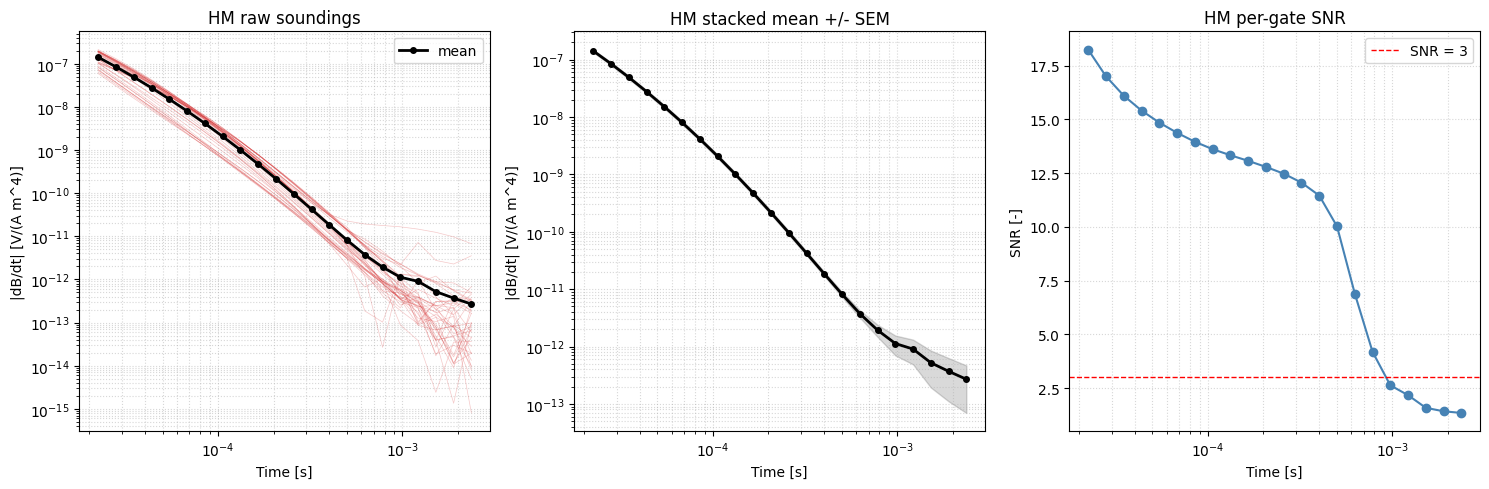

Gates with SNR >= 3: 17 / 22


In [12]:
MOMENT = 'HM'   # 'LM' for early-time only, 'HM' for full depth range

t_all  = tem.gate_times[MOMENT]['center']
d_all  = tem.dbdt(MOMENT)          # (n_stations, n_gates)
t_snr, mean, sem, snr = tem.snr(MOMENT)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Raw curves
ax = axes[0]
for row in d_all:
    ax.loglog(t_all, np.abs(row), color='tab:red', lw=0.5, alpha=0.25)
ax.loglog(t_all, np.abs(mean), 'k-o', ms=4, lw=2, label='mean')
ax.set_xlabel('Time [s]'); ax.set_ylabel('|dB/dt| [V/(A m^4)]')
ax.set_title(f'{MOMENT} raw soundings')
ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()

# Stacked mean with uncertainty
ax = axes[1]
band = sem
ax.fill_between(t_all, np.abs(mean) - band, np.abs(mean) + band, color='k', alpha=0.15)
ax.loglog(t_all, np.abs(mean), 'k-o', ms=4, lw=2)
ax.set_xlabel('Time [s]'); ax.set_ylabel('|dB/dt| [V/(A m^4)]')
ax.set_title(f'{MOMENT} stacked mean +/- SEM')
ax.grid(True, which='both', ls=':', alpha=0.5)

# SNR
ax = axes[2]
ax.semilogx(t_snr, snr, 'o-', color='steelblue')
ax.axhline(3, color='r', ls='--', lw=1, label='SNR = 3')
ax.set_xlabel('Time [s]'); ax.set_ylabel('SNR [-]')
ax.set_title(f'{MOMENT} per-gate SNR')
ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()

fig.tight_layout()
plt.show()

good = snr >= 3
print(f"Gates with SNR >= 3: {good.sum()} / {snr.size}")

## 3. Survey map and transect plots

UTM zone 35S  (EPSG:32735)  |  38 stations  |  3 lines


c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


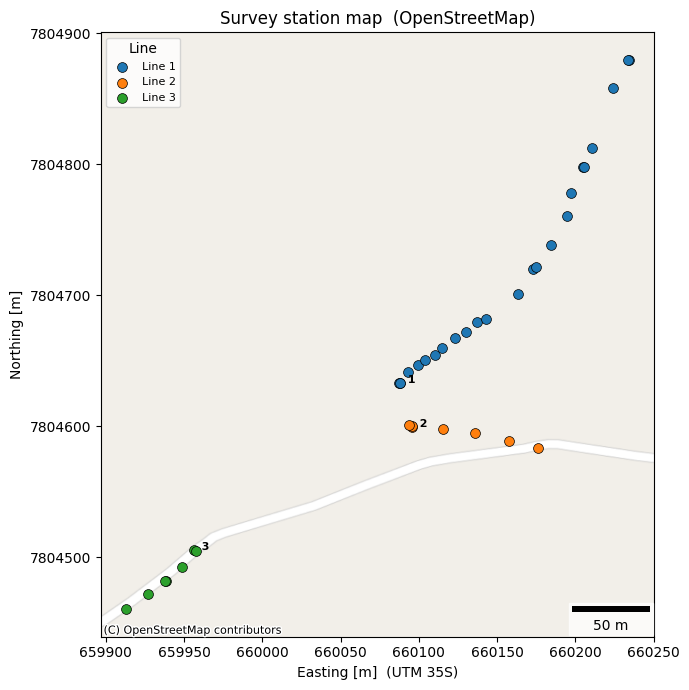

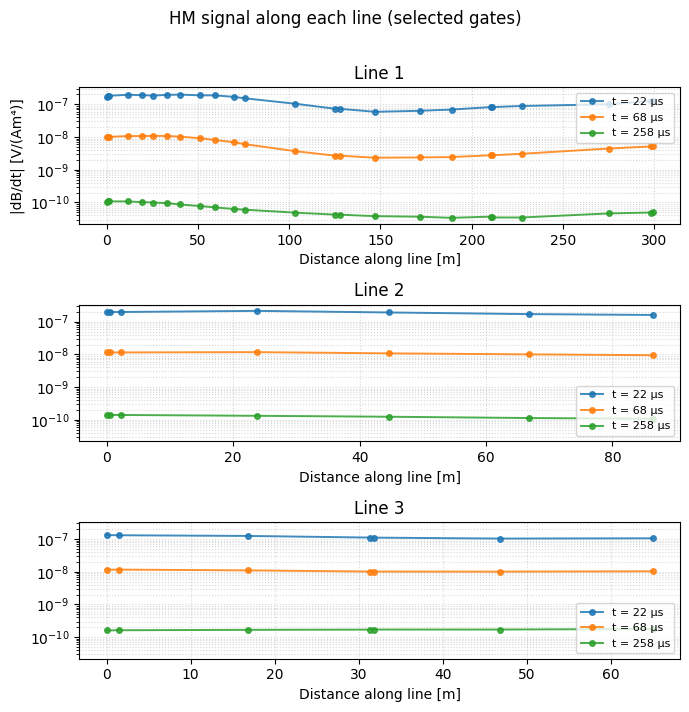

In [13]:
import contextily as ctx
from pyproj import Proj
from matplotlib_scalebar.scalebar import ScaleBar

# ── UTM projection ────────────────────────────────────────────────────────────
df = tem.data.copy()
df['Line'] = df['Line'].astype(str).str.strip()
lines = sorted(df['Line'].unique())
LINE_COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

lon_c = df['Longitude'].mean()
lat_c = df['Latitude'].mean()
zone  = int((lon_c + 180) / 6) + 1
hem   = 'north' if lat_c >= 0 else 'south'
utm   = Proj(proj='utm', zone=zone, ellps='WGS84', south=(hem == 'south'))
df['E'], df['N'] = utm(df['Longitude'].values, df['Latitude'].values)

epsg = 32600 + zone if hem == 'north' else 32700 + zone
print(f"UTM zone {zone}{hem[0].upper()}  (EPSG:{epsg})  |  {len(df)} stations  |  {len(lines)} lines")

# ── Distance helper ───────────────────────────────────────────────────────────
def _line_distance_utm(E, N):
    dE = np.diff(E); dN = np.diff(N)
    return np.concatenate([[0.0], np.cumsum(np.sqrt(dE**2 + dN**2))])

# ── Station map ───────────────────────────────────────────────────────────────
fig_map, ax_map = plt.subplots(figsize=(7, 7))

for i, line in enumerate(lines):
    sub = df[df['Line'] == line]
    ax_map.scatter(sub['E'], sub['N'],
                   c=LINE_COLORS[i % len(LINE_COLORS)], s=50,
                   label=f'Line {line}', zorder=4, edgecolors='k', linewidths=0.5)
    first = sub.iloc[0]
    ax_map.annotate(f'  {line}', (first['E'], first['N']),
                    fontsize=8, color='k', fontweight='bold', zorder=5)

try:
    ctx.add_basemap(ax_map, crs=f'EPSG:{epsg}',
                    source=ctx.providers.OpenStreetMap.Mapnik, zoom='auto')
    ax_map.set_title('Survey station map  (OpenStreetMap)')
except Exception as e:
    ax_map.set_title('Survey station map  (basemap unavailable)')
    ax_map.set_facecolor('#e8e8e8')
    ax_map.grid(True, ls=':', alpha=0.5)
    print(f"Basemap not loaded: {e}")

ax_map.set_xlabel(f'Easting [m]  (UTM {zone}{hem[0].upper()})')
ax_map.set_ylabel('Northing [m]')
ax_map.legend(title='Line', fontsize=8, loc='upper left', framealpha=0.8)
ax_map.add_artist(ScaleBar(1, units='m', location='lower right', box_alpha=0.7))
ax_map.ticklabel_format(style='plain', useOffset=False)
fig_map.tight_layout()
plt.show()

# ── Transects ─────────────────────────────────────────────────────────────────
GATE_COLS = ['HMgate001', 'HMgate006', 'HMgate012']
GATE_LBLS = [f't = {tem.gate_times["HM"]["center"][i]*1e6:.0f} µs'
             for i in (0, 5, 11)]

fig_tr, axes_tr = plt.subplots(len(lines), 1, figsize=(7, 7), sharey=True)
if len(lines) == 1:
    axes_tr = [axes_tr]

for ax_tr, line, color in zip(axes_tr, lines, LINE_COLORS):
    sub = df[df['Line'] == line].copy()
    dist = _line_distance_utm(sub['E'].values, sub['N'].values)
    for col, lbl in zip(GATE_COLS, GATE_LBLS):
        if col in sub.columns:
            vals = sub[col].replace(99999, np.nan).values.astype(float)
            ax_tr.semilogy(dist, np.abs(vals), 'o-', ms=4, lw=1.4,
                           label=lbl, alpha=0.85)
    ax_tr.set_xlabel('Distance along line [m]')
    ax_tr.set_title(f'Line {line}')
    ax_tr.grid(True, which='both', ls=':', alpha=0.5)
    ax_tr.legend(fontsize=8)

axes_tr[0].set_ylabel('|dB/dt| [V/(Am⁴)]')
fig_tr.suptitle('HM signal along each line (selected gates)', y=1.01)
fig_tr.tight_layout()
plt.show()

In [15]:
coords = df[['Line', 'Station', 'E', 'N', 'Elevation', 'Longitude', 'Latitude']].rename(columns={
    'E': 'UTM_E',
    'N': 'UTM_N',
}).reset_index(drop=True)

OUT_CSV = r'C:\Users\pamcl\Downloads\Kenbec\kenbec_stations_utm.csv'

# Write a CRS comment line before the data
with open(OUT_CSV, 'w') as f:
    f.write(f"# CRS: EPSG:{epsg}  (UTM zone {zone}{hem[0].upper()}, WGS84)  |  Lat/Lon: EPSG:4326\n")
    coords.to_csv(f, index=False)

print(f"Saved {len(coords)} stations to {OUT_CSV}")

Saved 38 stations to C:\Users\pamcl\Downloads\Kenbec\kenbec_stations_utm.csv


## 4. Prepare inversion inputs (both moments)

For a **joint LM + HM inversion** we prepare *both* moments. They share the
same loop / Rx geometry but have different transmitter waveforms and gate
times, so each moment is stored as its own "system".

`to_pytem` converts each moment to pyTEM format and scales the waveform by
`peak_current * tx_area * tx_turns` so that the unit of the forward response
matches the data unit V/(A m^4).

Set the peak transmitter currents from the field notes
(typical TEM2Go values: 1 A LM / 10-20 A HM).


In [16]:
from pytem import fwd_circle_offset, fwd_square_offset

# Peak transmitter current for each moment.
# LM (low moment) and HM (high moment) typically use different currents.
# Check your field notes — typical TEM2Go values are 1 A (LM) and 10–20 A (HM).
LM_CURRENT = 1.0    # [A]
HM_CURRENT = 10.0   # [A]

CURRENTS = {'LM': LM_CURRENT, 'HM': HM_CURRENT}
MOMENTS  = ['LM', 'HM']          # both moments are inverted jointly

# ── Sounding selection ────────────────────────────────────────────────────────
#   STATION = None   -> stack (mean) over all stations (best SNR, recommended)
#   STATION = <int>  -> invert a single station by row index (0 .. n_stations-1)
STATION = None
n_stations = len(tem.data)
if STATION is not None:
    STATION = int(STATION) % n_stations          # wrap so any int stays valid
print(f"Sounding : "
      f"{'stacked mean (all stations)' if STATION is None else f'station #{STATION}'}"
      f"  ({n_stations} stations available)")

# ── Loop geometry ─────────────────────────────────────────────────────────────
#   USE_SQUARE_LOOP = True   -> exact square offset loop (slower, more accurate)
#   USE_SQUARE_LOOP = False  -> equal-area circular offset loop (faster)
USE_SQUARE_LOOP = False

# Build one pyTEM "system" dict per moment. They share geometry but each has
# its own gate times, waveform and noise.
systems = {}
for _m in MOMENTS:
    _kw = tem.to_pytem(_m, peak_current=CURRENTS[_m], station=STATION)
    systems[_m] = _kw

# Geometry is shared across moments (same loop and Rx offset).
tx_side    = systems['HM']['tx_size']
rx_x, rx_y = systems['HM']['rx_x'], systems['HM']['rx_y']
_tx_r      = float(np.sqrt(tx_side**2 / np.pi))   # equal-area circle radius

GEOMETRY   = 'square_offset' if USE_SQUARE_LOOP else 'circle_offset'
TX_SIZE    = float(tx_side) if USE_SQUARE_LOOP else _tx_r   # side or radius
RX_X, RX_Y = abs(rx_x), abs(rx_y)


def fwd_step(thick, rho, times_step, n_quad_sq=5):
    """Step-off response (positive) for the selected offset geometry."""
    if USE_SQUARE_LOOP:
        return -fwd_square_offset(thick, rho, TX_SIZE, RX_X, RX_Y, times_step,
                                  current=1.0, signal=-1, n_quad=n_quad_sq,
                                  transform='dlf')
    return -fwd_circle_offset(thick, rho, TX_SIZE, RX_X, times_step,
                              current=1.0, signal=-1, transform='dlf')


print(f"Geometry : {GEOMETRY}  |  tx_side={tx_side} m   equal-area r={_tx_r:.2f} m   "
      f"Rx=({RX_X}, {RX_Y}) m")
print(f"Tx area  : {systems['HM']['tx_area']:.1f} m²   turns = {systems['HM']['tx_turns']}")
print()
for _m in MOMENTS:
    kw = systems[_m]
    t  = kw['times']
    print(f"{_m}: I={CURRENTS[_m]:>5.1f} A  gates={t.size:2d}  "
          f"[{t[0]:.2e} … {t[-1]:.2e}] s  "
          f"obs=[{kw['obs_data'].min():.2e} … {kw['obs_data'].max():.2e}] V/m²  "
          f"wf_I peak={kw['waveform_currents'].max():.1f} A-turns")


Sounding : stacked mean (all stations)  (38 stations available)
Geometry : circle_offset  |  tx_side=3.0 m   equal-area r=1.69 m   Rx=(13.0, 0.0) m
Tx area  : 9.0 m²   turns = 2

LM: I=  1.0 A  gates= 6  [1.09e-05 … 2.94e-05] s  obs=[1.30e-06 … 1.02e-05] V/m²  wf_I peak=2.0 A-turns
HM: I= 10.0 A  gates=22  [2.24e-05 … 2.37e-03] s  obs=[4.84e-11 … 2.56e-05] V/m²  wf_I peak=20.0 A-turns


## 5. Starting model

Smooth multi-layer parametrisation: log-spaced thicknesses, homogeneous
half-space starting resistivity.

In [17]:
N_LAYERS = 15

# Log-spaced thicknesses: thinner near surface, thicker at depth (N_LAYERS-1 values)
thicknesses = np.logspace(np.log10(2.0), np.log10(25.0), N_LAYERS - 1)

# Top depth of each of the N_LAYERS layers (including the half-space at the bottom)
# layers 1..N_LAYERS-1 have tops at cumsum(thicknesses[0:i]), half-space top at cumsum(all)
depths_top = np.concatenate([[0], np.cumsum(thicknesses)])   # N_LAYERS elements

# Starting model: conductive near surface, resistive basement
TRANSITION_DEPTH = 20.0   # [m]
RHO_SHALLOW      = 30.0   # [Ohm.m] above transition
RHO_DEEP         = 500.0  # [Ohm.m] below transition

rho_start_vec     = np.where(depths_top >= TRANSITION_DEPTH, RHO_DEEP, RHO_SHALLOW)
log_resistivities = np.log(rho_start_vec)   # N_LAYERS elements ✓

print(f"{N_LAYERS} layers, depth range 0 – {depths_top[-1]:.0f} m")
print(f"Starting model: {RHO_SHALLOW} Ohm.m above {TRANSITION_DEPTH} m, "
      f"{RHO_DEEP} Ohm.m below")
print(f"rho_start_vec: {rho_start_vec}")
assert len(thicknesses) == N_LAYERS - 1 and len(log_resistivities) == N_LAYERS



15 layers, depth range 0 – 132 m
Starting model: 30.0 Ohm.m above 20.0 m, 500.0 Ohm.m below
rho_start_vec: [ 30.  30.  30.  30.  30.  30. 500. 500. 500. 500. 500. 500. 500. 500.
 500.]


## 6. Joint LM + HM inversion

The built-in `invert` handles a single system. Here we recover **one**
resistivity model that fits **both** moments simultaneously. Each moment
contributes its own waveform-convolved forward response and Jacobian
(evaluated with `getJ_ana`); the two log-space Jacobians and residuals are
stacked and solved together with a smoothness-regularised Gauss-Newton step
(reusing pyTEM's `getR`, `getAlpha[s]`, and `_gn_solve`).

LM constrains the shallow structure (early times) and HM the deep structure
(late times), so the joint fit spans the full depth range.


In [18]:
import time as _time
from pytem import getJ_ana, getR, fwd_circle_offset, fwd_square_offset
from pytem.inversion import _alpha_search
from pytem.waveform import setup_waveform

def joint_invert(sys_list, thicknesses, log_resistivities, tx_size, rx_x,
                 rx_y=0.0, geometry='circle_offset', n_quad=5,
                 transform='dlf', hankel_filter='key_101', fourier_filter='key_81',
                 waveform_n_quad=5, maxit=20, alpha_start=None, alpha_steps=6,
                 alpha_step=1/9, rho_min=0.1, rho_max=1e5, plot_alpha=False,
                 verbose=True):
    """Joint regularised Gauss-Newton inversion of several TEM systems.

    All systems share one layered model (`thicknesses`, `log_resistivities`)
    and one loop geometry (`geometry`, `tx_size`, `rx_x`, `rx_y`), but each may
    have its own gate times, waveform, observed data and noise. The stacked
    (LM+HM) log-space problem is solved with pyTEM's alpha search, which cools
    the regularisation across iterations and targets RMS = 1 via a parabola fit.

    geometry : 'circle_offset' (tx_size = equal-area radius) or
               'square_offset' (tx_size = side length, integrated with n_quad).

    Each datum is weighted in log space by w = |obs| / noise_abs = 1 / noise_log.
    `noise_abs` must be a *per-gate* absolute error (typically frac * |obs|) so
    that every gate, early or late, is weighted by its own relative error.

    sys_list : list of dicts, each with keys
               'times', 'obs' (positive), 'noise_abs', 'wf_t', 'wf_I', 'name'.
    """
    m      = np.asarray(log_resistivities, float).copy()
    thick  = np.asarray(thicknesses, float)
    ln_lo, ln_hi = np.log(rho_min), np.log(rho_max)
    fwd_kw = dict(transform=transform, hankel_filter=hankel_filter,
                  fourier_filter=fourier_filter)

    # ---- Geometry dispatch (square vs circle offset loop) ----
    def _call_fwd(th, res, t):
        if geometry == 'square_offset':
            return -fwd_square_offset(th, res, tx_size, rx_x, rx_y, t,
                                      current=1.0, signal=-1, n_quad=n_quad, **fwd_kw)
        return -fwd_circle_offset(th, res, tx_size, rx_x, t,
                                  current=1.0, signal=-1, **fwd_kw)

    # ---- Precompute waveform quadrature + stacked obs / weights ----
    prep = []
    for s in sys_list:
        comp_t, apply_wf = setup_waveform(s['times'], s['wf_t'], s['wf_I'],
                                          n_quad=waveform_n_quad)
        obs = np.abs(np.asarray(s['obs'], float))
        w   = obs / np.asarray(s['noise_abs'], float)      # 1 / noise_log
        prep.append(dict(comp_t=comp_t, apply=apply_wf, w=w, obs=obs,
                         name=s['name']))
    obs_all = np.concatenate([p['obs'] for p in prep])
    w_all   = np.concatenate([p['w']   for p in prep])

    def _response(mm, p):
        """Waveform-convolved forward response (positive) + raw step response."""
        step = _call_fwd(thick, np.exp(mm), p['comp_t'])
        return p['apply'](step), step

    def _fwd_all(mm):
        """Stacked positive forward response across all systems."""
        return np.concatenate([_response(mm, p)[0] for p in prep])

    def _J_all(mm):
        """Stacked log-space Jacobian d ln(response)/d ln(rho) across systems."""
        parts = []
        for p in prep:
            g, step = _response(mm, p)
            J_anal = getJ_ana(thicknesses=thick, log_resistivities=mm,
                              tx_size=tx_size, times=p['comp_t'],
                              geometry=geometry, rx_x=rx_x, rx_y=rx_y,
                              n_quad=n_quad, use_cuda=False,
                              transform=transform, hankel_filter=hankel_filter,
                              fourier_filter=fourier_filter)
            dF = J_anal * step[:, None]          # absolute gradients at comp times
            dG = p['apply'](dF)                  # convolve gradients (chain rule)
            Jc = np.zeros((g.size, mm.size))
            vg = g > 0
            Jc[vg, :] = dG[vg, :] / g[vg, None]  # -> log-space Jacobian
            parts.append(Jc)
        return np.vstack(parts)

    # ---- Initial alpha heuristic (mirrors pytem.invert) ----
    J0 = _J_all(m)
    d0 = _fwd_all(m)
    valid0 = (obs_all > 0) & (d0 > 0)
    res0 = np.zeros_like(obs_all)
    res0[valid0] = np.log(obs_all[valid0]) - np.log(d0[valid0])
    if alpha_start is None:
        alpha_start = float(np.linalg.norm((J0 * w_all[:, None]).T @ (res0 * w_all),
                                           np.inf) + 1e-30)
    if verbose:
        print(f"Geometry: {geometry}  |  Alpha start = {alpha_start:.3f}  "
              f"({obs_all.size} data)")

    # ---- Gauss-Newton loop (alpha cooling + parabola, mirrors pytem.invert) ----
    rms_history   = []
    model_history = [m.copy()]
    d_pred = d0
    J_cur  = J0

    for it in range(maxit):
        valid = (obs_all > 0) & (d_pred > 0)
        res_log = np.zeros_like(obs_all)
        res_log[valid] = np.log(obs_all[valid]) - np.log(d_pred[valid])
        rms = np.sqrt(np.mean((w_all[valid] * res_log[valid]) ** 2))
        rms_history.append(rms)
        if verbose:
            print(f"Iteration {it + 1:>3d}:  RMS = {rms:.3f}")

        if rms <= 1.0:
            if verbose:
                print("  RMS <= 1 - converged.")
            break

        if it > 0:
            J_cur = _J_all(m)

        R  = getR(m)
        Jw = J_cur * w_all[:, None]
        dw = res_log * w_all

        alpha_h, rms_h, delta_h, mod_h = _alpha_search(
            alpha_start, alpha_steps, Jw, dw, R, m,
            thick, _fwd_all, obs_all, w_all,
            ln_lo, ln_hi, alpha_step=alpha_step,
            rms_current=rms, plot=plot_alpha,
        )

        # Occam selection: prefer the parabola (overshoot) entry, else the
        # largest alpha still reaching RMS <= 1, else the minimum-RMS step.
        rms_arr   = np.array(rms_h)
        overshoot = bool(np.any(rms_arr < 1.0))
        if overshoot:
            best_idx = len(rms_h) - 1
        else:
            below = rms_arr[rms_arr <= 1.0]
            if below.size > 0:
                best_idx = int(np.where(rms_arr == below.max())[0][-1])
            else:
                best_idx = int(np.argmin(rms_arr))

        if rms_h[best_idx] >= rms:
            if verbose:
                print("  No improvement found - stopping.")
            break

        # Cool alpha_start to one step above the best alpha found.
        alpha_start = alpha_h[best_idx] * (10.0 ** alpha_step)

        m      = np.clip(m + delta_h[best_idx], ln_lo, ln_hi)
        d_pred = mod_h[best_idx]
        model_history.append(m.copy())

        if overshoot:
            rms_history.append(rms_h[best_idx])
            break

    return dict(log_resistivities=m, resistivities=np.exp(m), thicknesses=thick,
                rms_history=rms_history, model_history=model_history,
                n_iter=len(model_history) - 1)


# ── Apply calibration, per-gate noise, and gate selection per moment ──────────
# IMPORTANT: TEM data spans several decades in amplitude, so noise must be a
# PER-GATE relative error. A floor tied to the global peak (e.g. 1% of the
# largest gate) would swamp every late-time gate and drive their weight to ~0,
# making RMS meaningless (the model could be 10x off yet still report RMS≈1).
MAX_NOISE        = 0.1    # drop gates whose fractional noise exceeds this
NOISE_FLOOR_FRAC = 0.01   # minimum per-gate relative error

sys_list = []
for _m in MOMENTS:
    kw       = systems[_m]
    cal      = kw.get('cal', 1.0)                    # scale factor (1.0 if uncalibrated)
    obs_cal  = kw['obs_data'] * cal
    frac     = kw['noise_std']                       # per-gate fractional error
    frac_eff = np.maximum(frac, NOISE_FLOOR_FRAC)    # per-gate relative floor
    noise_abs = frac_eff * obs_cal                   # per-gate absolute noise

    good = frac <= MAX_NOISE
    systems[_m]['obs_cal']   = obs_cal               # keep full arrays for plotting
    systems[_m]['noise_abs'] = noise_abs
    systems[_m]['good']      = good

    sys_list.append(dict(
        name      = _m,
        times     = kw['times'][good],
        obs       = obs_cal[good],
        noise_abs = noise_abs[good],
        wf_t      = kw['waveform_times'],
        wf_I      = kw['waveform_currents'],
    ))
    print(f"{_m}: kept {good.sum()}/{good.size} gates "
          f"(noise ≤ {MAX_NOISE*100:.0f}%)  |  "
          f"frac range [{frac[good].min()*100:.1f}% … {frac[good].max()*100:.1f}%]")

# ── Run joint inversion (geometry / tx_size / Rx set in cell 4) ────────────────
_t0 = _time.perf_counter()
result = joint_invert(
    sys_list          = sys_list,
    thicknesses       = thicknesses,
    log_resistivities = log_resistivities,
    tx_size           = TX_SIZE,
    rx_x              = RX_X,
    rx_y              = RX_Y,
    geometry          = GEOMETRY,
    n_quad            = 5,
    transform         = 'dlf',
    hankel_filter     = 'key_101',
    fourier_filter    = 'key_81',
    waveform_n_quad   = 5,
    maxit             = 20,
)
_elapsed = _time.perf_counter() - _t0

best_rho = result['resistivities']
rms_hist = result['rms_history']
rho_hist = [np.exp(m) for m in result['model_history']]

print(f"\nElapsed  : {_elapsed:.1f} s")
print(f"Final RMS = {rms_hist[-1]:.3f}  after {result['n_iter']} iterations")
print("Recovered resistivities [Ohm.m]:")
print(np.array2string(best_rho, precision=1))


LM: kept 6/6 gates (noise ≤ 10%)  |  frac range [3.7% … 6.0%]
HM: kept 15/22 gates (noise ≤ 10%)  |  frac range [5.5% … 10.0%]
Geometry: circle_offset  |  Alpha start = 2929.161  (21 data)
Iteration   1:  RMS = 24.926
    Alpha = 2929.16,  RMS = 4.15
    Alpha = 2267.94,  RMS = 3.94
    Alpha = 1755.99,  RMS = 3.78
    Alpha = 1359.60,  RMS = 3.68
    Alpha = 1052.69,  RMS = 3.64
    Alpha = 815.06,  RMS = 3.65
    RMS increased - stopping alpha search early.
Iteration   2:  RMS = 3.641
    Alpha = 1359.60,  RMS = 2.68
    Alpha = 1052.69,  RMS = 2.46
    Alpha = 815.06,  RMS = 2.26
    Alpha = 631.07,  RMS = 2.08
    Alpha = 488.61,  RMS = 1.92
    Alpha = 378.32,  RMS = 1.79
Iteration   3:  RMS = 1.789
    Alpha = 488.61,  RMS = 2.01
    Alpha = 378.32,  RMS = 1.79
    Alpha = 292.92,  RMS = 1.60
    Alpha = 226.79,  RMS = 1.42
    Alpha = 175.60,  RMS = 1.26
    Alpha = 135.96,  RMS = 1.14
Iteration   4:  RMS = 1.142
    Alpha = 175.60,  RMS = 1.56
    Alpha = 135.96,  RMS = 1.33
  